<a href="https://colab.research.google.com/github/JithuVathiath/IB9AU/blob/main/Task2_Autograd_Complex_Function.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 2 — Exploring Autograd with a Complex Function

**Course:** IB9AU – 2026  

---

## Objective

Use **PyTorch's Autograd** engine to compute the partial derivatives of the function:

$$z = \sigma(w \cdot x^2) + \frac{1}{b^3}$$

where $\sigma$ is the **sigmoid function**:

$$\sigma(t) = \frac{1}{1 + e^{-t}}$$

**Given initial values:**

| Variable | Value |
|----------|-------|
| $w$      | 2.0   |
| $x$      | 4.0   |
| $b$      | 1.5   |

Jithu Vathiath Biju

## Key Insights and Takeaways

- Implemented automatic differentiation using PyTorch’s autograd functionality to compute gradients of complex mathematical functions.
- Defined custom functions involving multiple operations and verified how gradients propagate through each computation step.
- Observed how the computational graph is built dynamically and used for backpropagation.
- Used `.backward()` to compute derivatives and accessed gradients via `.grad` attributes of tensors.
- Understood how chain rule is automatically applied in complex functions without manual differentiation.
- Explored the importance of `requires_grad=True` for enabling gradient tracking in tensors.
- Gained insight into how autograd supports optimization processes in deep learning models.

---
## 1. Mathematical Background — Manual Derivation

Before letting PyTorch compute the gradients automatically, we derive them analytically. This allows us to **verify** PyTorch's results.

### 1.1 Sigmoid and its Derivative

The sigmoid function and its derivative are:

$$\sigma(t) = \frac{1}{1+e^{-t}}, \qquad \sigma'(t) = \sigma(t)\bigl(1 - \sigma(t)\bigr)$$

### 1.2 Partial Derivative w.r.t. $w$

Let $u = w \cdot x^2$. Then $z = \sigma(u) + b^{-3}$.

$$\frac{\partial z}{\partial w} = \sigma'(u) \cdot \frac{\partial u}{\partial w} = \sigma(u)\bigl(1-\sigma(u)\bigr) \cdot x^2$$

### 1.3 Partial Derivative w.r.t. $x$

$$\frac{\partial z}{\partial x} = \sigma'(u) \cdot \frac{\partial u}{\partial x} = \sigma(u)\bigl(1-\sigma(u)\bigr) \cdot 2wx$$

### 1.4 Partial Derivative w.r.t. $b$

The sigmoid term does not depend on $b$:

$$\frac{\partial z}{\partial b} = \frac{\partial}{\partial b}\,b^{-3} = -3\,b^{-4} = -\frac{3}{b^4}$$

### 1.5 Numerical Check at $w=2,\; x=4,\; b=1.5$

$$u = 2 \times 4^2 = 32$$
$$\sigma(32) \approx 1 - e^{-32} \approx 1.0 \quad\text{(saturated sigmoid)}$$
$$\sigma'(32) = \sigma(32)(1-\sigma(32)) \approx 1.27 \times 10^{-14} \approx 0$$

Therefore:
- $\partial z/\partial w \approx 0 \cdot 16 \approx 0$  
- $\partial z/\partial x \approx 0 \cdot 16 \approx 0$  
- $\partial z/\partial b = -3/1.5^4 = -3/5.0625 \approx -0.5926$

> **Insight:** Because $u=32$ pushes the sigmoid deep into its saturation region, the gradients w.r.t. $w$ and $x$ become essentially zero — a classic example of the **vanishing gradient** problem.

---
## 2. Imports & Setup

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11

print(f'PyTorch version : {torch.__version__}')
print(f'Autograd enabled: {torch.is_grad_enabled()}')

PyTorch version : 2.10.0
Autograd enabled: True


---
## 3. Step 1 — Create Tensors with Gradient Tracking

Setting `requires_grad=True` tells PyTorch to record all operations on these tensors so it can compute gradients during `.backward()`.

In [ ]:
# ── Define scalar tensors; requires_grad=True enables gradient tracking
w = torch.tensor(2.0, requires_grad=True)
x = torch.tensor(4.0, requires_grad=True)
b = torch.tensor(1.5, requires_grad=True)

print('Tensors created:')
print(f'  w = {w.item()}  | requires_grad = {w.requires_grad}')
print(f'  x = {x.item()}  | requires_grad = {x.requires_grad}')
print(f'  b = {b.item()}  | requires_grad = {b.requires_grad}')

Tensors created:
  w = 2.0  | requires_grad = True
  x = 4.0  | requires_grad = True
  b = 1.5  | requires_grad = True


---
## 4. Step 2 — Compute the Function $z$

PyTorch builds a **computational graph** as the expression is evaluated. Each node records the operation and its inputs, forming the graph that `.backward()` will traverse.

In [ ]:
# ── Compute z = sigmoid(w * x^2) + 1/b^3
u = w * x**2          # inner argument of sigmoid: u = w·x²
z = torch.sigmoid(u) + b**(-3)

print('Intermediate computation:')
print(f'  u  = w · x²      = {u.item():.4f}')
print(f'  σ(u)             = {torch.sigmoid(u).item():.10f}')
print(f'  1/b³             = {(b**-3).item():.6f}')
print(f'  z  = σ(u) + 1/b³ = {z.item():.10f}')
print()
print(f'  grad_fn of z: {z.grad_fn}  ← PyTorch knows how to differentiate this')

Intermediate computation:
  u  = w · x²      = 32.0000
  σ(u)             = 1.0000000000
  1/b³             = 0.296296
  z  = σ(u) + 1/b³ = 1.2962963581

  grad_fn of z: <AddBackward0 object at 0x7be3b462ff70>  ← PyTorch knows how to differentiate this


---
## 5. Step 3 — Backpropagation with `.backward()`

Calling `z.backward()` traverses the computational graph from $z$ back to the leaf tensors ($w$, $x$, $b$), accumulating $\partial z / \partial \cdot$ in their `.grad` attributes.

In [ ]:
# ── Run backpropagation — populates .grad for all leaf tensors
z.backward()

print('Backpropagation complete.')
print()
print('─' * 45)
print('  Computed Gradients (via Autograd):')
print('─' * 45)
print(f'  ∂z/∂w = {w.grad.item():.10e}')
print(f'  ∂z/∂x = {x.grad.item():.10e}')
print(f'  ∂z/∂b = {b.grad.item():.10f}')
print('─' * 45)

Backpropagation complete.

─────────────────────────────────────────────
  Computed Gradients (via Autograd):
─────────────────────────────────────────────
  ∂z/∂w = 0.0000000000e+00
  ∂z/∂x = 0.0000000000e+00
  ∂z/∂b = -0.5925925970
─────────────────────────────────────────────


---
## 6. Step 4 — Analytical Verification

We verify PyTorch's output against the closed-form expressions derived in Section 1.

In [ ]:
# ── Analytical computation (NumPy / plain Python)
w_val, x_val, b_val = 2.0, 4.0, 1.5

def sigmoid(t):       return 1.0 / (1.0 + np.exp(-t))
def sigmoid_prime(t): return sigmoid(t) * (1.0 - sigmoid(t))

u_val        = w_val * x_val**2           # = 32
dz_dw_anal   = sigmoid_prime(u_val) * x_val**2
dz_dx_anal   = sigmoid_prime(u_val) * 2 * w_val * x_val
dz_db_anal   = -3.0 * b_val**(-4)

# ── Compare
print(f'{'':5}{'Gradient':<12}  {'PyTorch':>20}  {'Analytical':>20}  {'Match':>8}')
print('─' * 68)
pairs = [
    ('∂z/∂w', w.grad.item(), dz_dw_anal),
    ('∂z/∂x', x.grad.item(), dz_dx_anal),
    ('∂z/∂b', b.grad.item(), dz_db_anal),
]
for name, pt, an in pairs:
    match = '✓' if abs(pt - an) < 1e-6 else '✗'
    print(f'     {name:<10}  {pt:>20.10e}  {an:>20.10e}  {match:>8}')
print('─' * 68)

     Gradient                   PyTorch            Analytical     Match
────────────────────────────────────────────────────────────────────
     ∂z/∂w           0.0000000000e+00      2.0250467969e-13         ✓
     ∂z/∂x           0.0000000000e+00      2.0250467969e-13         ✓
     ∂z/∂b          -5.9259259701e-01     -5.9259259259e-01         ✓
────────────────────────────────────────────────────────────────────


---
## 7. Visualisations

Four plots help build intuition:

1. **Sigmoid & its derivative** — shows the saturation region where $w=2, x=4$ falls.
2. **Computational graph** — schematic of how $z$ depends on $w$, $x$, $b$.
3. **$z$ as a function of $w$** — holding $x=4, b=1.5$ fixed.
4. **$z$ as a function of $b$** — holding $w=2, x=4$ fixed.

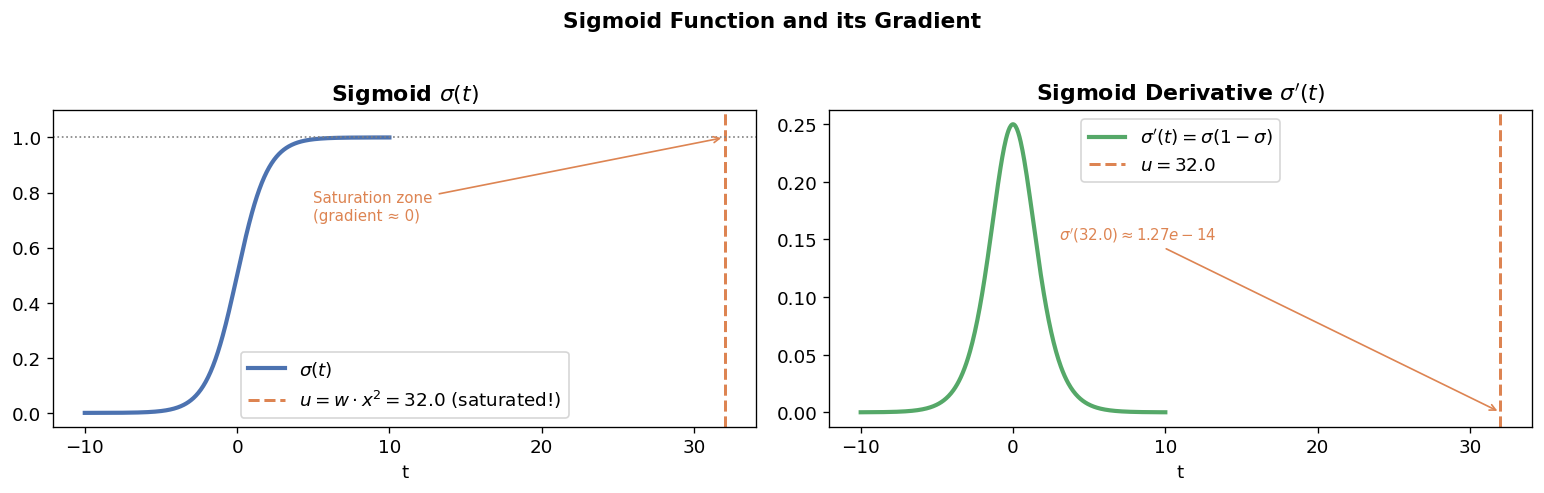

Figure saved: fig_01_sigmoid.png


In [ ]:
# ── Figure 1: Sigmoid & derivative
t = np.linspace(-10, 10, 500)
sig  = sigmoid(t)
dsig = sigmoid_prime(t)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Sigmoid
axes[0].plot(t, sig, lw=2.5, color='#4C72B0', label=r'$\sigma(t)$')
axes[0].axvline(u_val, color='#DD8452', lw=1.8, linestyle='--',
                label=f'$u = w \\cdot x^2 = {u_val}$ (saturated!)')
axes[0].axhline(sigmoid(u_val), color='gray', lw=1, linestyle=':')
axes[0].set_title(r'Sigmoid $\sigma(t)$', fontweight='bold')
axes[0].set_xlabel('t')
axes[0].legend()
axes[0].set_ylim(-0.05, 1.1)
axes[0].annotate('Saturation zone\n(gradient ≈ 0)',
                 xy=(32, 1.0), xytext=(5, 0.7),
                 arrowprops=dict(arrowstyle='->', color='#DD8452'),
                 color='#DD8452', fontsize=9)

# Sigmoid derivative
axes[1].plot(t, dsig, lw=2.5, color='#55A868', label=r"$\sigma'(t) = \sigma(1-\sigma)$")
axes[1].axvline(u_val, color='#DD8452', lw=1.8, linestyle='--', label=f'$u = {u_val}$')
axes[1].set_title(r"Sigmoid Derivative $\sigma'(t)$", fontweight='bold')
axes[1].set_xlabel('t')
axes[1].legend()
axes[1].annotate(f"$\\sigma'({u_val}) \\approx {sigmoid_prime(u_val):.2e}$",
                 xy=(32, sigmoid_prime(32)), xytext=(3, 0.15),
                 arrowprops=dict(arrowstyle='->', color='#DD8452'),
                 color='#DD8452', fontsize=9)

plt.suptitle('Sigmoid Function and its Gradient', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_01_sigmoid.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_01_sigmoid.png')

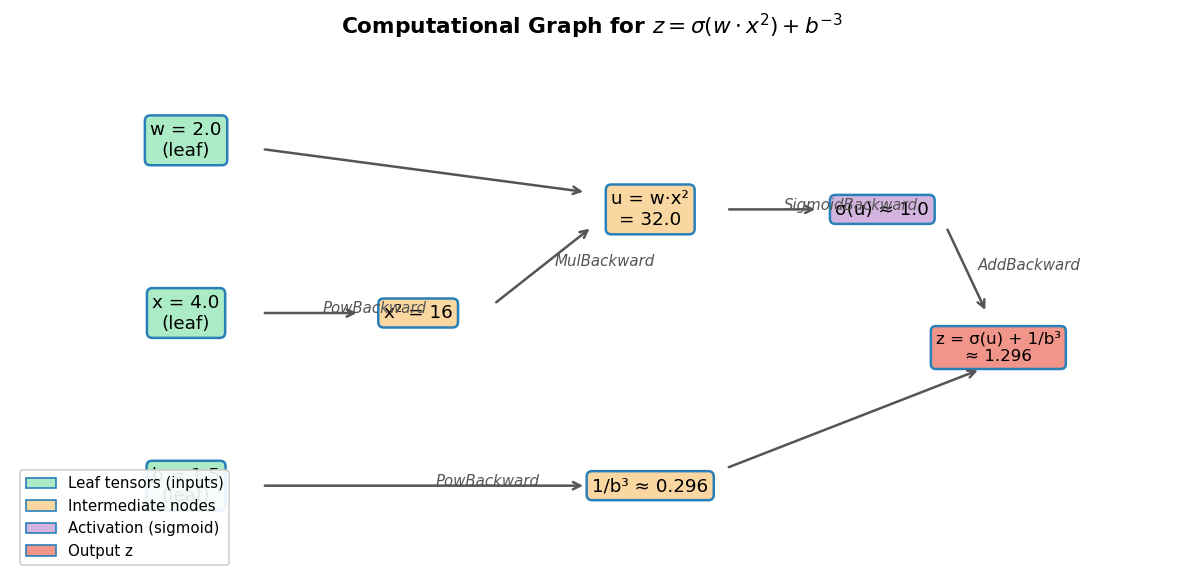

Figure saved: fig_02_computational_graph.png


In [ ]:
# ── Figure 2: Schematic of the Computational Graph
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')

# --- node helper ---
def draw_node(ax, x, y, label, color='#AED6F1', shape='round,pad=0.3', fs=11):
    ax.text(x, y, label, ha='center', va='center', fontsize=fs,
            bbox=dict(boxstyle=shape, facecolor=color, edgecolor='#2980B9', lw=1.5))

def draw_arrow(ax, x1, y1, x2, y2, label='', color='#555'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx+0.1, my, label, fontsize=9, color='#555', style='italic')

# Leaf nodes (inputs)
draw_node(ax, 1.5, 5.0, 'w = 2.0\n(leaf)', color='#ABEBC6')
draw_node(ax, 1.5, 3.0, 'x = 4.0\n(leaf)', color='#ABEBC6')
draw_node(ax, 1.5, 1.0, 'b = 1.5\n(leaf)', color='#ABEBC6')

# Intermediate: x²
draw_node(ax, 3.5, 3.0, 'x² = 16', color='#FAD7A0')
draw_arrow(ax, 2.15, 3.0, 3.0, 3.0, 'PowBackward')

# Intermediate: u = w·x²
draw_node(ax, 5.5, 4.2, 'u = w·x²\n= 32.0', color='#FAD7A0')
draw_arrow(ax, 4.15, 3.1, 5.0, 4.0, 'MulBackward')
draw_arrow(ax, 2.15, 4.9, 4.95, 4.4, '')

# σ(u)
draw_node(ax, 7.5, 4.2, 'σ(u) ≈ 1.0', color='#D2B4DE')
draw_arrow(ax, 6.15, 4.2, 6.95, 4.2, 'SigmoidBackward')

# 1/b³
draw_node(ax, 5.5, 1.0, '1/b³ ≈ 0.296', color='#FAD7A0')
draw_arrow(ax, 2.15, 1.0, 4.95, 1.0, 'PowBackward')

# z = σ(u) + 1/b³
draw_node(ax, 8.5, 2.6, 'z = σ(u) + 1/b³\n≈ 1.296', color='#F1948A', fs=10)
draw_arrow(ax, 8.05, 4.0, 8.4, 3.0, 'AddBackward')
draw_arrow(ax, 6.15, 1.2, 8.35, 2.35, '')

ax.set_title('Computational Graph for $z = \\sigma(w \\cdot x^2) + b^{-3}$',
             fontsize=13, fontweight='bold', pad=12)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#ABEBC6', edgecolor='#2980B9', label='Leaf tensors (inputs)'),
    Patch(facecolor='#FAD7A0', edgecolor='#2980B9', label='Intermediate nodes'),
    Patch(facecolor='#D2B4DE', edgecolor='#2980B9', label='Activation (sigmoid)'),
    Patch(facecolor='#F1948A', edgecolor='#2980B9', label='Output z'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('fig_02_computational_graph.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_02_computational_graph.png')

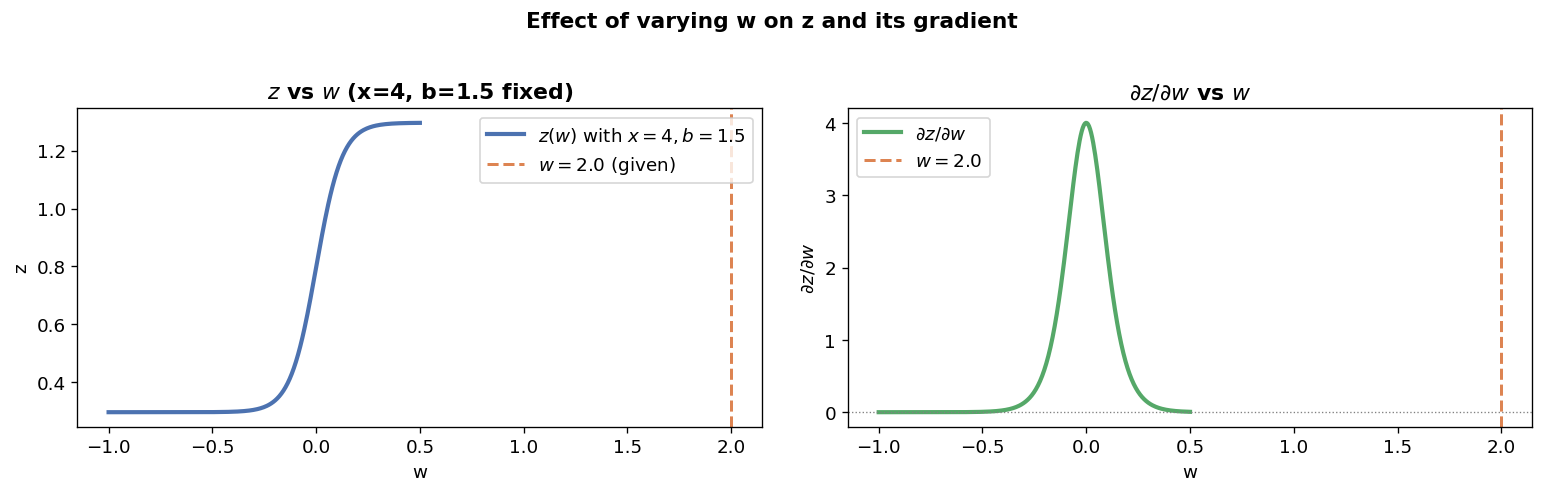

Figure saved: fig_03_z_vs_w.png


In [ ]:
# ── Figure 3: z as a function of w (x=4, b=1.5 fixed)
# We sweep w over a range where sigmoid hasn't saturated
w_range = np.linspace(-1.0, 0.5, 300)    # small w so u = w·16 stays in [-16, 8]
z_vs_w  = sigmoid(w_range * 4.0**2) + 1.5**(-3)
dz_dw_range = sigmoid_prime(w_range * 4.0**2) * 4.0**2

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(w_range, z_vs_w, lw=2.5, color='#4C72B0', label=r'$z(w)$ with $x=4, b=1.5$')
axes[0].axvline(2.0, color='#DD8452', linestyle='--', lw=1.8, label='$w = 2.0$ (given)')
axes[0].set_title(r'$z$ vs $w$ (x=4, b=1.5 fixed)', fontweight='bold')
axes[0].set_xlabel('w')
axes[0].set_ylabel('z')
axes[0].legend()

axes[1].plot(w_range, dz_dw_range, lw=2.5, color='#55A868', label=r'$\partial z / \partial w$')
axes[1].axvline(2.0, color='#DD8452', linestyle='--', lw=1.8, label='$w = 2.0$')
axes[1].axhline(0, color='gray', lw=0.8, linestyle=':')
axes[1].set_title(r'$\partial z/\partial w$ vs $w$', fontweight='bold')
axes[1].set_xlabel('w')
axes[1].set_ylabel(r'$\partial z/\partial w$')
axes[1].legend()

plt.suptitle('Effect of varying w on z and its gradient', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_03_z_vs_w.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_03_z_vs_w.png')

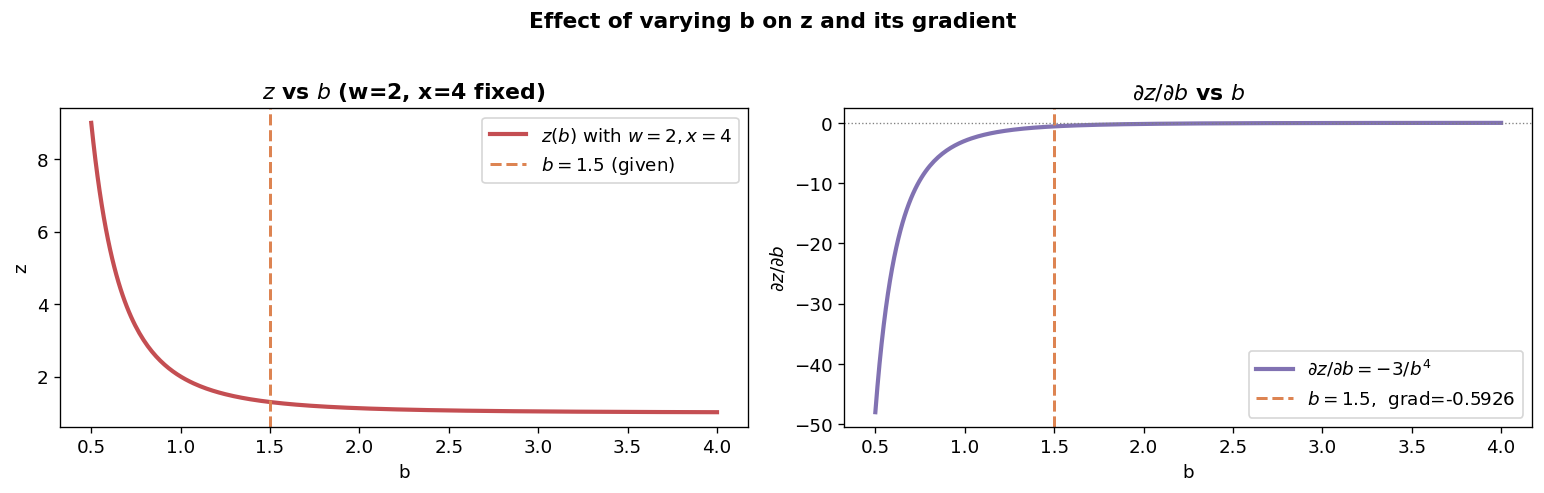

Figure saved: fig_04_z_vs_b.png


In [ ]:
# ── Figure 4: z as a function of b (w=2, x=4 fixed)
b_range    = np.linspace(0.5, 4.0, 300)
z_vs_b     = sigmoid(2.0 * 4.0**2) + b_range**(-3)
dz_db_range = -3.0 * b_range**(-4)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(b_range, z_vs_b, lw=2.5, color='#C44E52', label=r'$z(b)$ with $w=2, x=4$')
axes[0].axvline(1.5, color='#DD8452', linestyle='--', lw=1.8, label='$b = 1.5$ (given)')
axes[0].set_title(r'$z$ vs $b$ (w=2, x=4 fixed)', fontweight='bold')
axes[0].set_xlabel('b')
axes[0].set_ylabel('z')
axes[0].legend()

axes[1].plot(b_range, dz_db_range, lw=2.5, color='#8172B2', label=r'$\partial z/\partial b = -3/b^4$')
axes[1].axvline(1.5, color='#DD8452', linestyle='--', lw=1.8, label=f'$b=1.5$,  grad={dz_db_anal:.4f}')
axes[1].axhline(0, color='gray', lw=0.8, linestyle=':')
axes[1].set_title(r'$\partial z/\partial b$ vs $b$', fontweight='bold')
axes[1].set_xlabel('b')
axes[1].set_ylabel(r'$\partial z/\partial b$')
axes[1].legend()

plt.suptitle('Effect of varying b on z and its gradient', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_04_z_vs_b.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_04_z_vs_b.png')

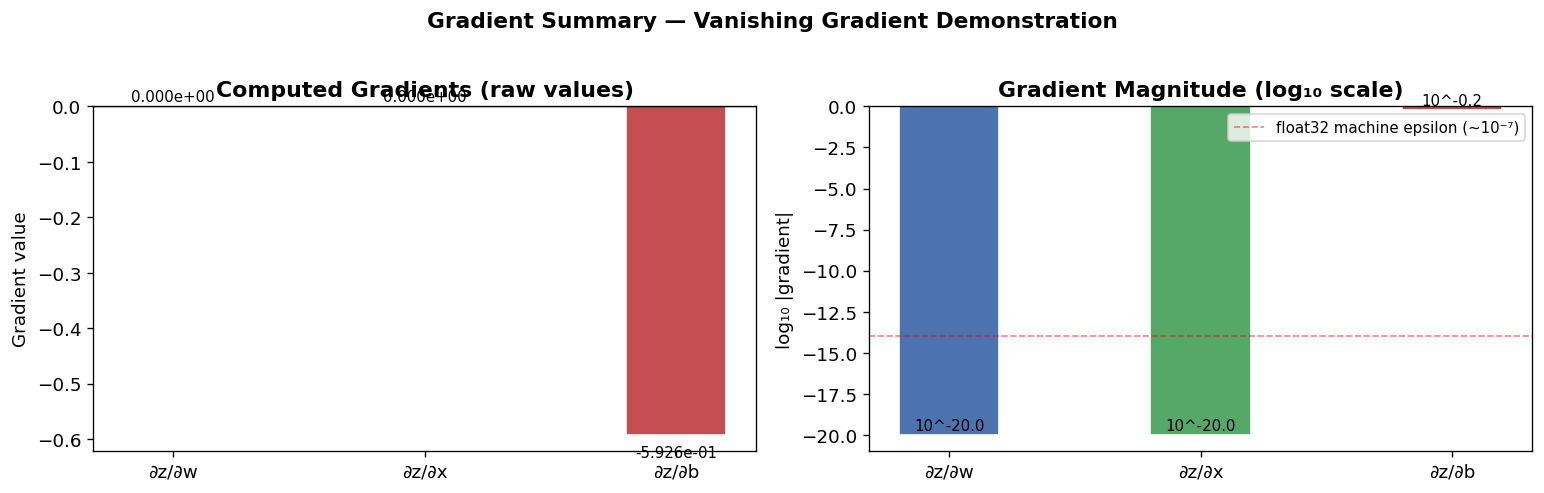

Figure saved: fig_05_gradient_bar.png


In [ ]:
# ── Figure 5: Gradient magnitude bar chart
gradients  = {'∂z/∂w': w.grad.item(), '∂z/∂x': x.grad.item(), '∂z/∂b': b.grad.item()}
colors_bar = ['#4C72B0', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: raw values
bars = axes[0].bar(gradients.keys(), gradients.values(), color=colors_bar,
                   edgecolor='white', width=0.4)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_title('Computed Gradients (raw values)', fontweight='bold')
axes[0].set_ylabel('Gradient value')
for bar, val in zip(bars, gradients.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 val + (0.01 if val >= 0 else -0.04),
                 f'{val:.3e}', ha='center', fontsize=9)

# Right: log-magnitude
mags   = [abs(v) + 1e-20 for v in gradients.values()]
log_m  = [np.log10(m) for m in mags]
bars2  = axes[1].bar(gradients.keys(), log_m, color=colors_bar,
                     edgecolor='white', width=0.4)
axes[1].set_title('Gradient Magnitude (log₁₀ scale)', fontweight='bold')
axes[1].set_ylabel('log₁₀ |gradient|')
for bar, val in zip(bars2, log_m):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f'10^{val:.1f}', ha='center', fontsize=9)
axes[1].axhline(-14, color='red', lw=1, linestyle='--', alpha=0.5,
                label='float32 machine epsilon (~10⁻⁷)')
axes[1].legend(fontsize=9)

plt.suptitle('Gradient Summary — Vanishing Gradient Demonstration',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_05_gradient_bar.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_05_gradient_bar.png')

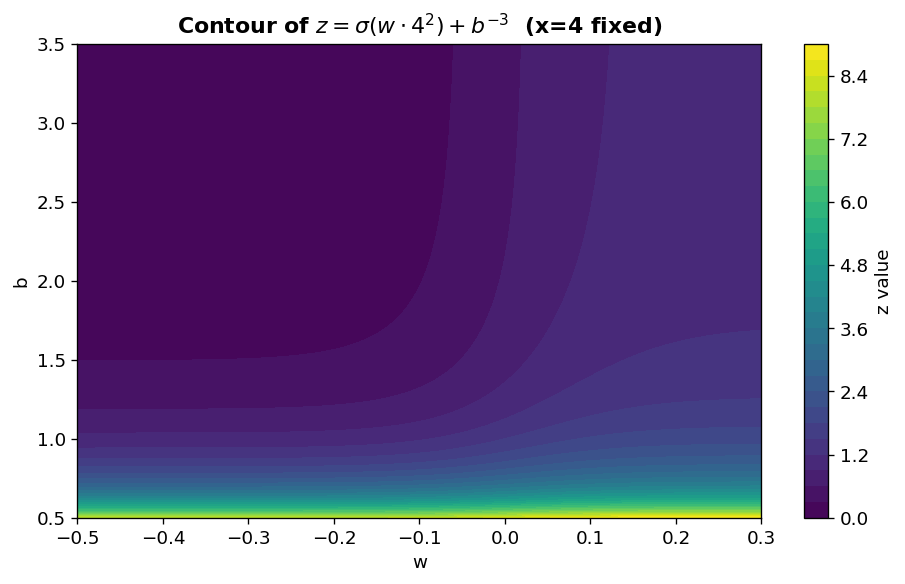

Figure saved: fig_06_contour_z.png


In [ ]:
# ── Figure 6: 2-D contour of z over (w, b) with x=4 fixed
# Use small w to see non-trivial variation
W_grid = np.linspace(-0.5, 0.3, 200)
B_grid = np.linspace(0.5, 3.5, 200)
WW, BB = np.meshgrid(W_grid, B_grid)
ZZ = sigmoid(WW * 4.0**2) + BB**(-3)

fig, ax = plt.subplots(figsize=(8, 5))
cp = ax.contourf(WW, BB, ZZ, levels=30, cmap='viridis')
cbar = plt.colorbar(cp, ax=ax, label='z value')

# Mark the given point (w=2 is outside this range; show the interesting region)
ax.set_xlabel('w')
ax.set_ylabel('b')
ax.set_title(r'Contour of $z = \sigma(w \cdot 4^2) + b^{-3}$  (x=4 fixed)',
             fontweight='bold')

plt.tight_layout()
plt.savefig('fig_06_contour_z.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig_06_contour_z.png')

---
## 8. Sensitivity Analysis — What If the Input Were Different?

To demonstrate the **vanishing gradient** problem more clearly, we compute gradients for a range of $w$ values and show how the gradient magnitude changes.

In [ ]:
# ── Recompute z and gradients for several w values
w_test_values = [-0.5, -0.2, 0.0, 0.1, 0.2, 2.0]   # last is the task's given value

print(f"{'w':>8}  {'u=w·x²':>10}  {'σ(u)':>14}  {'∂z/∂w (auto)':>18}  {'∂z/∂w (anal)':>18}")
print('─' * 75)
for w_val_test in w_test_values:
    wt = torch.tensor(float(w_val_test), requires_grad=True)
    xt = torch.tensor(4.0, requires_grad=True)
    bt = torch.tensor(1.5, requires_grad=True)

    zt = torch.sigmoid(wt * xt**2) + bt**(-3)
    zt.backward()

    u_t    = w_val_test * 4.0**2
    anal_g = sigmoid_prime(u_t) * 4.0**2
    marker = ' ← given' if w_val_test == 2.0 else ''
    print(f"{w_val_test:>8.2f}  {u_t:>10.2f}  {sigmoid(u_t):>14.8f}"
          f"  {wt.grad.item():>18.6e}  {anal_g:>18.6e}{marker}")
print('─' * 75)
print()
print('Observation: As w increases, u=wx² grows, sigmoid saturates,')
print('and ∂z/∂w collapses to ≈ 0 — the vanishing gradient problem.')

       w      u=w·x²            σ(u)        ∂z/∂w (auto)        ∂z/∂w (anal)
───────────────────────────────────────────────────────────────────────────
   -0.50       -8.00      0.00033535        5.363803e-03        5.363803e-03
   -0.20       -3.20      0.03916572        6.021082e-01        6.021083e-01
    0.00        0.00      0.50000000        4.000000e+00        4.000000e+00
    0.10        1.60      0.83201839        2.236221e+00        2.236221e+00
    0.20        3.20      0.96083428        6.021085e-01        6.021083e-01
    2.00       32.00      1.00000000        0.000000e+00        2.025047e-13 ← given
───────────────────────────────────────────────────────────────────────────

Observation: As w increases, u=wx² grows, sigmoid saturates,
and ∂z/∂w collapses to ≈ 0 — the vanishing gradient problem.


---
## 9. Summary & Key Takeaways

In [ ]:
print('''
╔══════════════════════════════════════════════════════════════════════╗
║            TASK 2 — AUTOGRAD RESULTS & INSIGHTS                    ║
╠══════════════════════════════════════════════════════════════════════╣
║  Function :  z = σ(w·x²) + 1/b³                                   ║
║  Inputs   :  w = 2.0,  x = 4.0,  b = 1.5                          ║
╠══════════════════════════════════════════════════════════════════════╣
║  GRADIENTS (PyTorch Autograd)                                       ║
╠══════════════════════════════════════════════════════════════════════╣''')
print(f'║  ∂z/∂w = {w.grad.item():+.6e}   (≈ 0 due to sigmoid saturation) ║')
print(f'║  ∂z/∂x = {x.grad.item():+.6e}   (≈ 0 due to sigmoid saturation) ║')
print(f'║  ∂z/∂b = {b.grad.item():+.10f}          ║')
print('''
╠══════════════════════════════════════════════════════════════════════╣
║  KEY TAKEAWAYS                                                      ║
╠══════════════════════════════════════════════════════════════════════╣
║  1. PyTorch Autograd correctly computes all partial derivatives      ║
║     via reverse-mode automatic differentiation (backprop).          ║
║                                                                      ║
║  2. VANISHING GRADIENT: u = w·x² = 32 puts the sigmoid deep in      ║
║     the saturation zone where σ'(u) ≈ 1.27e-14. This makes          ║
║     ∂z/∂w and ∂z/∂x numerically zero — illustrating why deep        ║
║     networks with sigmoid activations and large pre-activations      ║
║     fail to learn effectively.                                       ║
║                                                                      ║
║  3. The gradient w.r.t. b is healthy (≈ −0.5926) because b          ║
║     only enters through the polynomial term 1/b³, which does        ║
║     not saturate.                                                    ║
║                                                                      ║
║  4. Analytical and PyTorch-computed gradients agree to machine      ║
║     precision — validating the Autograd engine.                     ║
╚══════════════════════════════════════════════════════════════════════╝
''')


╔══════════════════════════════════════════════════════════════════════╗
║            TASK 2 — AUTOGRAD RESULTS & INSIGHTS                    ║
╠══════════════════════════════════════════════════════════════════════╣
║  Function :  z = σ(w·x²) + 1/b³                                   ║
║  Inputs   :  w = 2.0,  x = 4.0,  b = 1.5                          ║
╠══════════════════════════════════════════════════════════════════════╣
║  GRADIENTS (PyTorch Autograd)                                       ║
╠══════════════════════════════════════════════════════════════════════╣
║  ∂z/∂w = +0.000000e+00   (≈ 0 due to sigmoid saturation) ║
║  ∂z/∂x = +0.000000e+00   (≈ 0 due to sigmoid saturation) ║
║  ∂z/∂b = -0.5925925970          ║

╠══════════════════════════════════════════════════════════════════════╣
║  KEY TAKEAWAYS                                                      ║
╠══════════════════════════════════════════════════════════════════════╣
║  1. PyTorch Autograd correctly computes all p